In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
mali_path = "/home/mila/m/myriam.lizotte/MALI"
scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"

# save_name = f"ablation_fosta_params" #dataset}".format(dataset = dataset_name)
# save_path = f"{scratch_path}/results/{save_name}"


load results

In [21]:
exp = "ablation_fosta_params/9122531"
results_path = f"/home/mila/m/myriam.lizotte/scratch/RF-MALI/results/{exp}"

# load results
results_df = pd.read_csv(f"{results_path}/simulated_multimodal_results.csv")

# in the df, replace "_" with " " 
results_df['split'] = results_df['split'].str.replace('_', ' ')
results_df.columns = results_df.columns.str.replace('_', ' ')

# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['model', 'dataset', 'split', 'seed'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')

# take the abs for silhouette domain because it should be low, doesnt matter the sign
results_df['Silhouette domain'] = results_df['Silhouette domain'].abs()

# remove RFMALI
methods_to_remove= ["RFMALI"]
results_df = results_df[~results_df["model"].isin(methods_to_remove)]
results_df

,seed,split,dataset,model,FOSCTTM,Silhouette domain,Accuracy missing,Accuracy visible,Alignment score,Time seconds,Peak memory MB
0,14532986,random,balance_scale,fosta,0.498332,0.000362,0.586538,0.584665,0.508400,20.455898,116.095755
1,14532986,random,balance_scale,fosta_no_prior_normalization,0.502644,0.000913,0.612179,0.645367,0.592267,18.539217,146.653419
2,14532986,random,balance_scale,fosta_euclidean,0.498179,0.000034,0.573718,0.565495,0.344400,10.419616,56.316072
4,41184989,random,balance_scale,fosta,0.502508,0.000159,0.564103,0.607029,0.405200,20.592863,115.715205
5,41184989,random,balance_scale,fosta_no_prior_normalization,0.502978,0.000684,0.538462,0.632588,0.432400,18.662271,146.292270
...,...,...,...,...,...,...,...,...,...,...,...
1622,29501205,rotate,tic-tac-toe,fosta_no_prior_normalization,0.379428,0.043108,0.411273,0.482255,0.510329,28.260331,271.065510
1623,29501205,rotate,tic-tac-toe,fosta_euclidean,0.355913,0.000024,0.807933,0.812109,0.979782,19.211446,119.481992
1625,14532986,rotate,tic-tac-toe,fosta,0.336138,0.056695,0.415449,0.440501,0.384573,31.638323,280.314554
1626,14532986,rotate,tic-tac-toe,fosta_no_prior_normalization,0.339156,0.053603,0.438413,0.480167,0.431711,28.538882,274.901949


In [22]:
results_df.value_counts(["split"], sort=True)

split                 
add noise features        213
random                    207
alternating importance    204
rotate                    201
importance                195
distort                   195
25.713248252868652          1
10.476503375917673          1
10.24443975649774           1
0.8469387755102041          1
11.150887087918818          1
37.59366893768311           1
54.052988052368164          1
Name: count, dtype: int64

In [9]:
results_df["split"].unique()

array(['random', 'importance', 'alternating importance',
       'add noise features', 'distort', 'rotate', nan,
       '10.461648947093636'], dtype=object)

average over all datasets

In [10]:
summary_df = results_df.groupby(['split','model'])[num_cols].mean()
summary_df_std = results_df.groupby(['split','model'])[num_cols].std()
summary_df

Accuracy missing  \
split                  model                                            
add noise features     fosta                                 0.593697   
                       fosta_euclidean                       0.734289   
                       fosta_no_prior_normalization          0.635762   
alternating importance fosta                                 0.745735   
                       fosta_euclidean                       0.732425   
                       fosta_no_prior_normalization          0.750017   
distort                fosta                                 0.730538   
                       fosta_euclidean                       0.779380   
                       fosta_no_prior_normalization          0.719520   
importance             fosta                                 0.727823   
                       fosta_euclidean                       0.731825   
                       fosta_no_prior_normalization          0.730208   
random                 fosta                                 0.721053   
                       fosta_euclidean                       0.721945   
                       fosta_no_prior_normalization          0.713873   
rotate                 fosta                                 0.758259   
                       fosta_euclidean                       0.792725   
                       fosta_no_prior_normalization          0.761740   

                                                     Accuracy visible  \
split                  model                                            
add noise features     fosta                                 0.628209   
                       fosta_euclidean                       0.751474   
                       fosta_no_prior_normalization          0.662249   
alternating importance fosta                                 0.760783   
                       fosta_euclidean                       0.760005   
                       fosta_no_prior_normalization          0.766065   
distort                fosta                                 0.766332   
                       fosta_euclidean                       0.807156   
                       fosta_no_prior_normalization          0.755601   
importance             fosta                                 0.734935   
                       fosta_euclidean                       0.746211   
                       fosta_no_prior_normalization          0.746722   
random                 fosta                                 0.740670   
                       fosta_euclidean                       0.764974   
                       fosta_no_prior_normalization          0.733811   
rotate                 fosta                                 0.792792   
                       fosta_euclidean                       0.815101   
                       fosta_no_prior_normalization          0.788684   

                                                     Alignment score  \
split                  model                                           
add noise features     fosta                                0.419927   
                       fosta_euclidean                      0.858652   
                       fosta_no_prior_normalization         0.525158   
alternating importance fosta                                0.689849   
                       fosta_euclidean                      0.859051   
                       fosta_no_prior_normalization         0.740680   
distort                fosta                                0.752932   
                       fosta_euclidean                      0.930296   
                       fosta_no_prior_normalization         0.805284   
importance             fosta                                0.584368   
                       fosta_euclidean                      0.754901   
                       fosta_no_prior_normalization         0.640822   
random                 fosta                                0.670205   
                       fosta_euclidean             

In [11]:
# clean summary_df 

def clean_summary_df(df):
    # remove "RFMALI" 
    df = df.loc[df.index.get_level_values('model') != 'RFMALI']

    cols_to_keep = ["Accuracy missing", "Alignment score", "FOSCTTM"]
    # rename Accuracy missing to Accuracy
    df = df[cols_to_keep]
    df = df.rename(columns={"Accuracy missing": "Accuracy"})
    return df

summary_df = clean_summary_df(summary_df)
summary_df_std = clean_summary_df(summary_df_std)

In [12]:
summary_df_fmt = format_top_3(summary_df)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(summary_df_fmt.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{lllll}
\toprule
 &  & Accuracy & Alignment score & FOSCTTM \\
split & model &  &  &  \\
\midrule
\multirow[t]{3}{*}{add noise features} & fosta & 0.594 & 0.420 & 0.237 \\
 & fosta_euclidean & 0.734 & 0.859 & 0.369 \\
 & fosta_no_prior_normalization & 0.636 & 0.525 & 0.223 \\
\cline{1-5}
\multirow[t]{3}{*}{alternating importance} & fosta & 0.746 & 0.690 & 0.334 \\
 & fosta_euclidean & 0.732 & \textit{0.859} & 0.359 \\
 & fosta_no_prior_normalization & 0.750 & 0.741 & 0.328 \\
\cline{1-5}
\multirow[t]{3}{*}{distort} & fosta & 0.731 & 0.753 & 0.231 \\
 & fosta_euclidean & \underline{0.779} & \underline{0.930} & 0.268 \\
 & fosta_no_prior_normalization & 0.720 & 0.805 & \textbf{0.218} \\
\cline{1-5}
\multirow[t]{3}{*}{importance} & fosta & 0.728 & 0.584 & 0.349 \\
 & fosta_euclidean & 0.732 & 0.755 & 0.368 \\
 & fosta_no_prior_normalization & 0.730 & 0.641 & 0.344 \\
\cline{1-5}
\multirow[t]{3}{*}{random} & fosta & 0.721 & 0.670 & 0.341 \\
 & fosta_euclidean & 0.722 & 0.836

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.594' '0.734' '0.636' '0.746' '0.732' '0.750' '0.731'
 '\\underline{0.779}' '0.720' '0.728' '0.732' '0.730' '0.721' '0.722'
 '0.714' '0.758' '\\textbf{0.793}' '\\textit{0.762}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:211: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.420' '0.859' '0.525' '0.690' '\\textit{0.859}' '0.741' '0.753'
 '\\underline{0.930}' '0.805' '0.584' '0.755' '0.641' '0.670' '0.836'
 '0.701' '0.744' '\\textbf{0.969}' '0.790']' has dtype incompatible with float64, please explicitly cast to a compatible 

# line plots

# memory and time

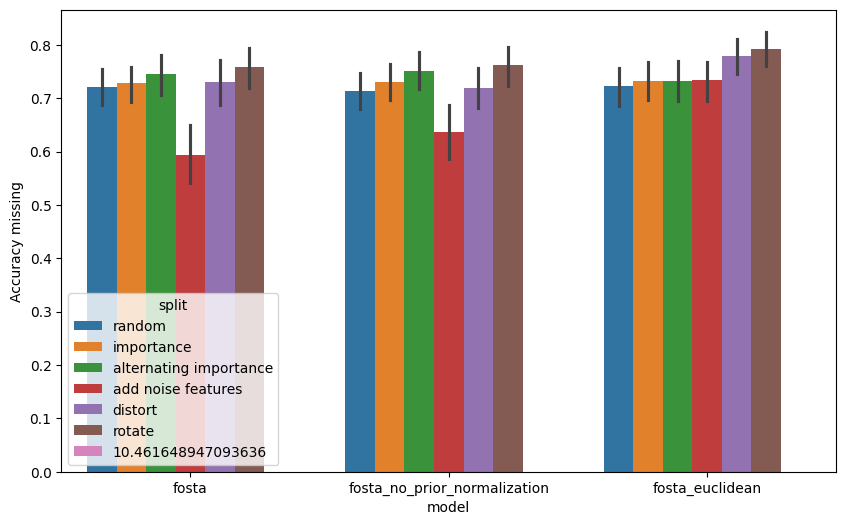

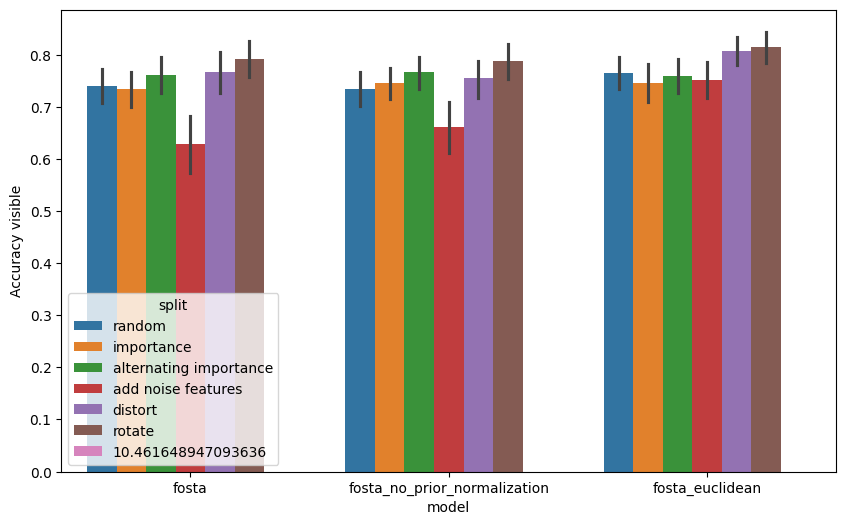

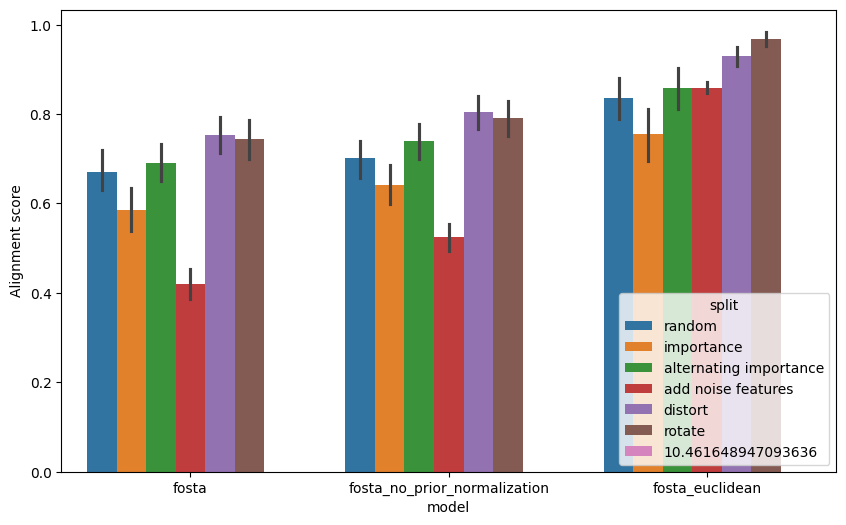

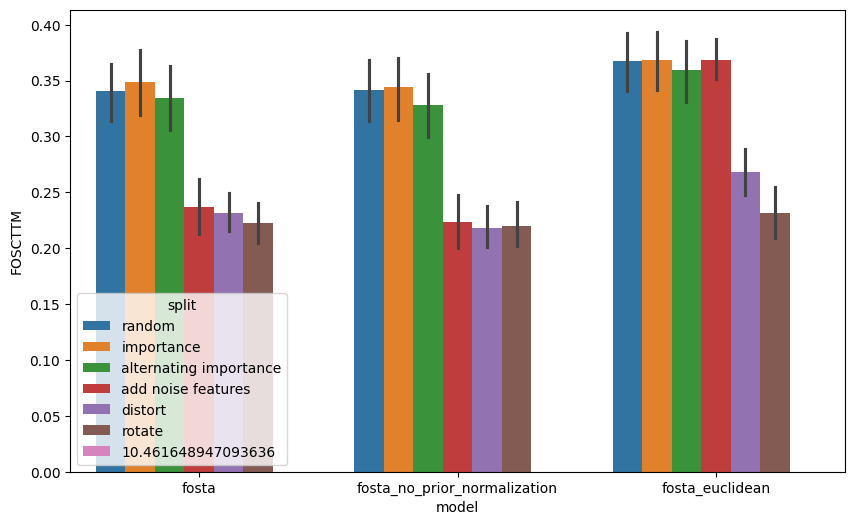

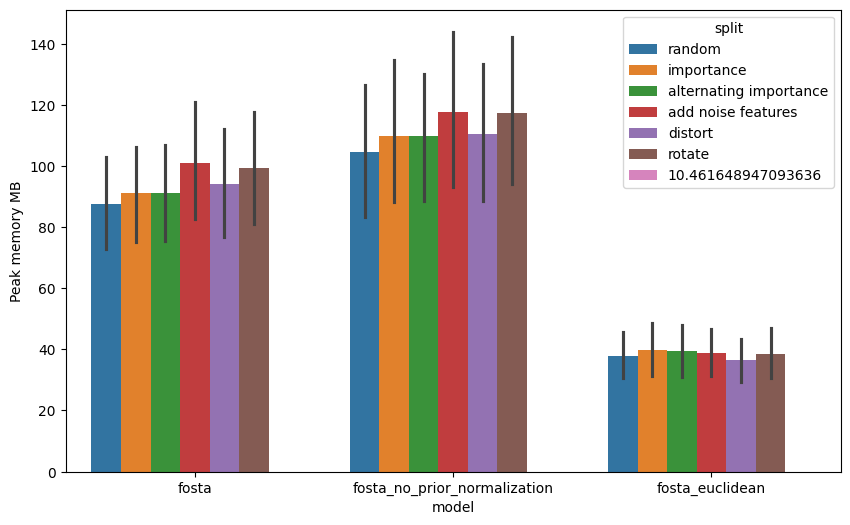

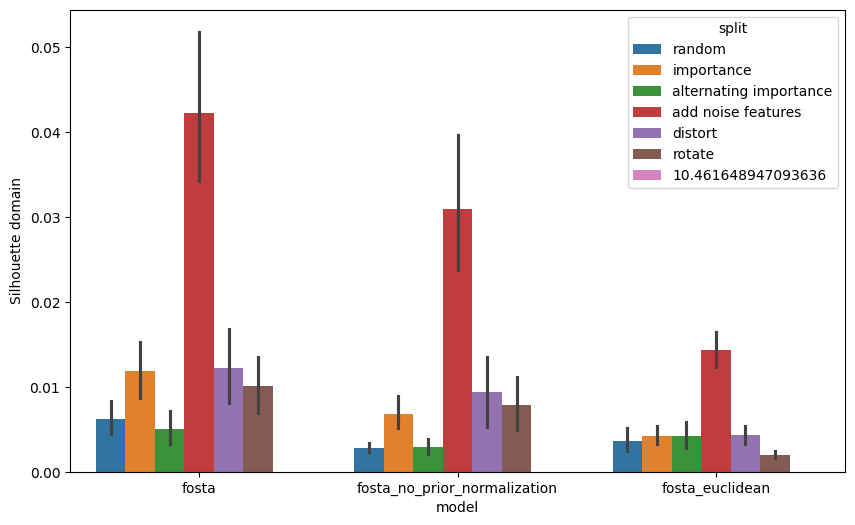

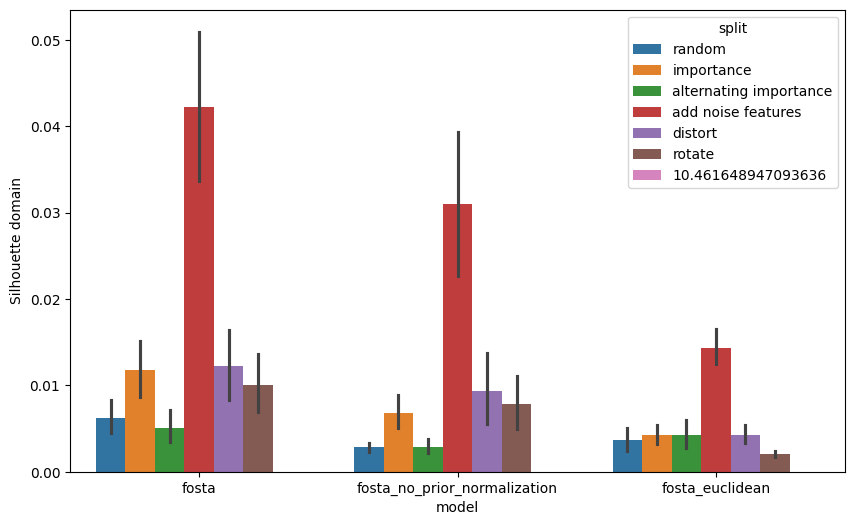

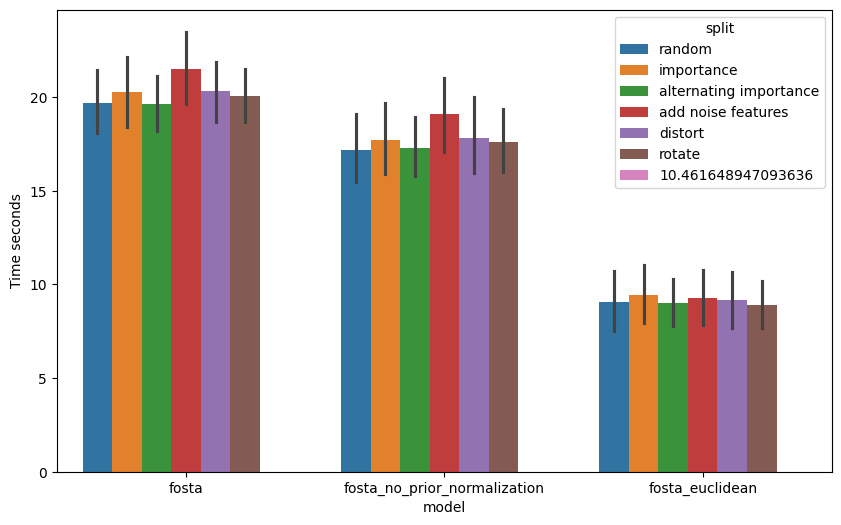

In [15]:
subset_df = results_df

for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.barplot(data=subset_df, x='model', y=col, hue='split')
    
    
    if col == "Silhouette domain":
        plt.figure(figsize=(10,6))
        sns.barplot(data=subset_df, x='model', y=col, hue='split')
        plt.show()